In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum
import random

In [2]:
def generate_random_colors(k):
    colors = []
    for _ in range(k):
        color = "#{:06x}".format(random.randint(0, 0xFFFFFF))
        colors.append(color)
    return colors

In [3]:
def create_graph(n = 10, p = 0.3):
    # G = nx.petersen_graph()  
    # G = nx.cycle_graph(6)  
    # G = nx.grid_2d_graph(3,3)  
    # G = nx.random_graphs.watts_strogatz_graph(10, 3, 0.5)  # Grafo di Watts-Strogatz

    G = nx.erdos_renyi_graph(n=n, p=p)


    
    V = list(G.nodes)
    E = list(G.edges)
    K = len(V)  # massimo numero di colori possibili

    # 2. Visualizzazione iniziale
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos, with_labels=True, node_color='lightgray', edge_color='gray')
    plt.title("Grafo da colorare")
    plt.show()

    return G, V, E, K, pos


## Problema di colorazione di un grafo

### Obiettivo
Colorare i nodi di un grafo non orientato in modo che **nodi adiacenti non abbiano lo stesso colore**, usando **il minor numero possibile di colori**.

---

### Input
Un grafo non orientato $( G = (\mathcal{V}, E) )$ dove:


$\mathcal{V} = \{1, \dots, n\} \quad \text{Insieme dei nodi}$ \
$E = \{1, \dots, m\} \quad \text{Insieme degli archi}$ \
$K$ colori disponibili (in genere $( K = |\mathcal{V}| )$ per garantire la fattibilità)

$$ 
x_{v,c} =
\begin{cases} 
1 \quad \quad \text{se al nodo } v \in \mathcal{V} \quad \text{è assegnato il colore} \quad c \, \in \{1, \dots, K\} \\
0 \quad \quad \text{altrimenti}
\end{cases}
$$

$$ 
y_c =
\begin{cases} 
1 \quad \quad \text{se il colore } c \in K \quad \text{viene utilizzato da almeno un nodo}\\
0 \quad \quad \text{altrimenti}
\end{cases}
$$




### Funzione obiettivo
Minimizzare il numero totale di colori usati:


$$
\begin{align}
&&   \min_{\boldsymbol{y} \, \in \, \{0, 1\}} \sum_{c=1}^{K} y_c \\

&&   \sum_{c=1}^{K} \quad x_{vc}  \,  & = 1,       &  \forall             \,                     v \in \mathcal{V}, \\
&&   x_{u,c} + x_{v,c}            \,    & \leq y_c   & \forall (u,v) \in E, \, \forall c \in \{1,\dots,K\}, \\
&&   x_{v,c}                      \,    & \leq y_c   & \forall v \in \mathcal{V},     \, \forall c \in \{1,\dots,K\}, \\
\end{align}
$$

### Note
- Il problema è un classico esempio di **Programmazione Lineare Intera Binaria**.
- È **NP-hard**, ma si possono trovare buone soluzioni per grafi piccoli o medi.
- La formulazione si presta bene a essere visualizzata graficamente per favorire la comprensione.


In [4]:
def solve_model_CG(V, E, K):

    # 3. Modello Gurobi
    model = Model("GraphColoring")
    x = {}  # variabili binarie per nodo-colore
    y = {}  # variabili binarie per uso colore

    x = model.addVars(V, K, vtype=GRB.BINARY, name="x")
    y = model.addVars(K, vtype=GRB.BINARY, name="y")

    # Vincolo: ogni nodo ha esattamente un colore
    for v in V:
        model.addConstr(quicksum(x[v, c] for c in range(K)) == 1)

    # Vincolo: nodi adiacenti non possono avere lo stesso colore
    for u, v in E:
        for c in range(K):
            model.addConstr(x[u, c] + x[v, c] <= y[c])

    # Vincolo: attivazione dei colori
    for v in V:
        for c in range(K):
            model.addConstr(x[v, c] <= y[c])

    # Funzione obiettivo: minimizzare i colori usati
    model.setObjective(quicksum(y[c] for c in range(K)), GRB.MINIMIZE)

    model.setParam("OutputFlag", 0)  # silenzioso
    model.optimize()

    return model, x, y



In [5]:
def color_graph(model, x, V, K, G, pos, palette_colors):

    # 4. Visualizzazione del risultato
    if model.status == GRB.OPTIMAL:
        color_map = {}
        for v in V:
            for c in range(K):
                if x[v, c].x > 0.5:
                    color_map[v] = c
                    break


        plt.figure(figsize=(6, 6))
        node_colors = [palette_colors[color_map[v]] for v in V]
        nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color='gray')
        plt.title(f"Colorazione ottima con {int(model.ObjVal)} colori")
        plt.show()
    else:
        print("Nessuna soluzione trovata.")



## Example

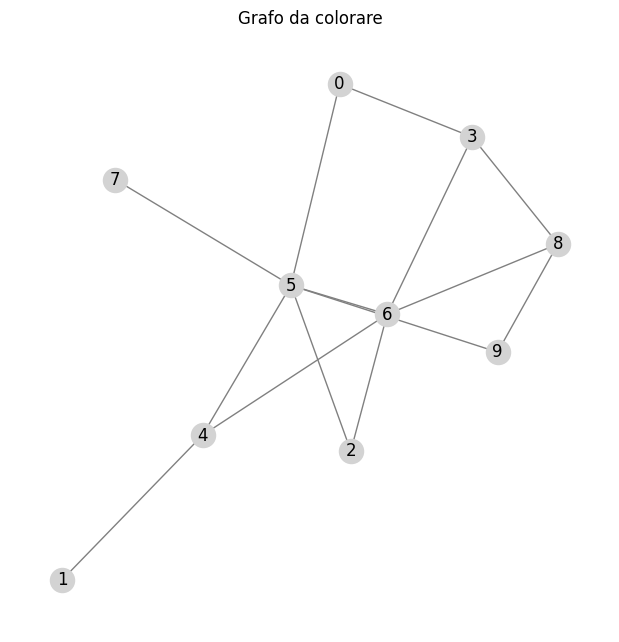

In [9]:
G, V, E, K, pos = create_graph(n = 10)

palette_colors = generate_random_colors(K)




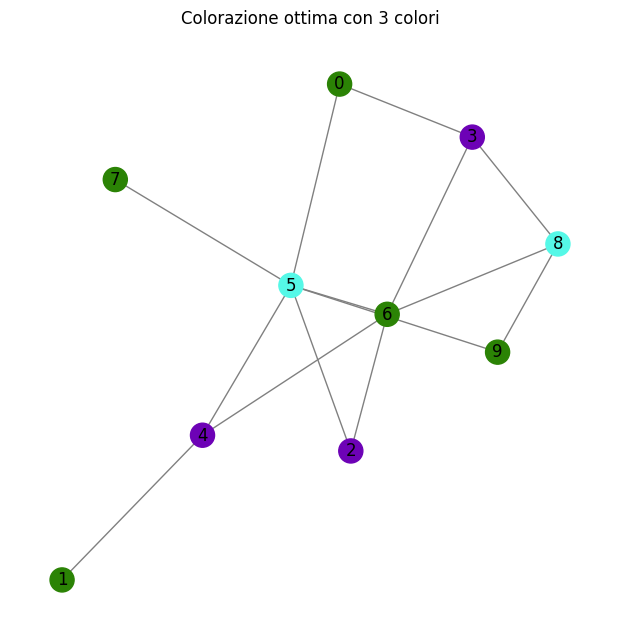

In [10]:
model, x, y = solve_model_CG(V, E, K)

color_graph(model, x, V, K, G, pos, palette_colors)